In [1]:
import numpy as np

class CliffWalkingEnv:
    def __init__(self):
        self.rows = 4
        self.cols = 12
        self.start_state = (3, 0)
        self.goal_state = (3, 11)
        self.state = self.start_state

        self.UP = 0
        self.DOWN = 1
        self.LEFT = 2
        self.RIGHT = 3

    def reset(self) -> tuple:
        self.state = self.start_state
        return self.state

    def step(self, action: int) -> tuple:
        r, c = self.state

        if action == self.UP:
            r -= 1
        elif action == self.DOWN:
            r += 1
        elif action == self.LEFT:
            c -= 1
        elif action == self.RIGHT:
            c += 1

        r = max(0, min(r, self.rows - 1))
        c = max(0, min(c, self.cols - 1))

        self.state = (r, c)

        if self.state == self.goal_state:
            return self.state, 0, True

        elif self.state[0] == 3 and 1 <= self.state[1] <= 10:
            self.state = self.start_state
            return self.state, -100, False

        else:
            return self.state, -20, False

    def render(self):
        for i in range(self.rows):
            row_str = ""
            for j in range(self.cols):
                if (i, j) == self.state:
                    row_str += " A "
                elif (i, j) == self.goal_state:
                    row_str += " G "
                elif i == 3 and 1 <= j <= 10:
                    row_str += " ~ "
                elif (i, j) == self.start_state:
                    row_str += " S "
                else:
                    row_str += " . "
            print(row_str)
        print("-" * 35)

In [2]:
Q_table = np.zeros((4, 12, 4))

def epsilon_greedy_policy(Q, state, epsilon, env):
    if np.random.rand() < epsilon:
        return np.random.choice([env.UP, env.DOWN, env.LEFT, env.RIGHT])
    else:
        r, c = state
        return np.argmax(Q[r, c])

In [3]:
def q_learning(env, num_episodes=500, alpha=0.1, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.rows, env.cols, 4))
    rewards_per_episode = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy_policy(Q, state, epsilon, env)

            next_state, reward, done = env.step(action)
            total_reward += reward

            r, c = state
            nr, nc = next_state

            best_next_val = np.max(Q[nr, nc])

            if done:
                best_next_val = 0.0

            td_target = reward + gamma * best_next_val
            td_error = td_target - Q[r, c, action]
            Q[r, c, action] = Q[r, c, action] + alpha * td_error

            state = next_state

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

In [4]:
def sarsa(env, num_episodes=500, alpha=0.1, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.rows, env.cols, 4))
    rewards_per_episode = []

    for episode in range(num_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        action = epsilon_greedy_policy(Q, state, epsilon, env)

        while not done:
            next_state, reward, done = env.step(action)
            total_reward += reward

            next_action = epsilon_greedy_policy(Q, next_state, epsilon, env)

            r, c = state
            nr, nc = next_state

            next_val = Q[nr, nc, next_action]

            if done:
                next_val = 0.0

            td_target = reward + gamma * next_val
            td_error = td_target - Q[r, c, action]
            Q[r, c, action] = Q[r, c, action] + alpha * td_error

            state = next_state
            action = next_action

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode

Antrenare Q-learning...
Antrenare SARSA...


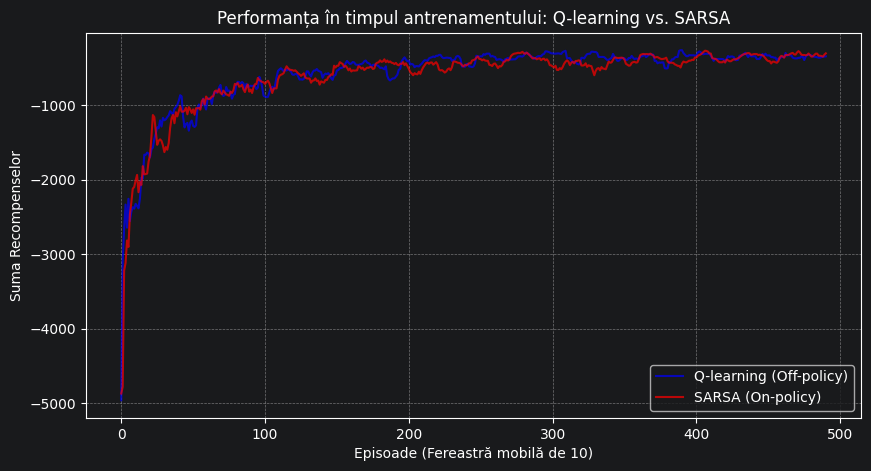


--- Politica Greedy: Q-learning (Drumul pe margine) ---
 ↓  ↑  →  ↑  ↓  →  →  →  →  ↑  ←  ↓ 
 ↑  ↑  →  →  ↓  →  →  →  →  →  ↓  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ~  ~  ~  ~  ~  ~  ~  ~  ~  ~  G 

--- Politica Greedy: SARSA (Drumul sigur) ---
 →  →  →  ↓  →  →  →  →  →  →  ↓  ↓ 
 ↑  →  →  →  →  →  →  →  →  →  →  ↓ 
 →  →  →  →  →  →  →  →  →  →  →  ↓ 
 ↑  ~  ~  ~  ~  ~  ~  ~  ~  ~  ~  G 


In [5]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

env = CliffWalkingEnv()

print("Antrenare Q-learning...")
q_table_qlearning, rewards_qlearning = q_learning(env)

print("Antrenare SARSA...")
q_table_sarsa, rewards_sarsa = sarsa(env)

def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

smoothed_qlearning = moving_average(rewards_qlearning)
smoothed_sarsa = moving_average(rewards_sarsa)

plt.figure(figsize=(10, 5))
plt.plot(smoothed_qlearning, label='Q-learning (Off-policy)', color='blue', alpha=0.7)
plt.plot(smoothed_sarsa, label='SARSA (On-policy)', color='red', alpha=0.7)
plt.xlabel('Episoade (Fereastră mobilă de 10)')
plt.ylabel('Suma Recompenselor')
plt.title('Performanța în timpul antrenamentului: Q-learning vs. SARSA')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

def print_policy(Q, env, title):
    arrows = {env.UP: '↑', env.DOWN: '↓', env.LEFT: '←', env.RIGHT: '→'}
    print(f"\n--- Politica Greedy: {title} ---")

    for r in range(env.rows):
        row_str = ""
        for c in range(env.cols):
            if r == 3 and 1 <= c <= 10:
                row_str += " ~ "
            elif (r, c) == env.goal_state:
                row_str += " G "
            else:
                best_action = np.argmax(Q[r, c])
                row_str += f" {arrows[best_action]} "
        print(row_str)

print_policy(q_table_qlearning, env, "Q-learning (Drumul pe margine)")
print_policy(q_table_sarsa, env, "SARSA (Drumul sigur)")

In [6]:
import time
from IPython.display import clear_output

def test_agent_with_render(env, Q_table):
    state = env.reset()
    done = False

    while not done:
        clear_output(wait=True)
        env.render()
        time.sleep(0.5)

        r, c = state
        action = np.argmax(Q_table[r, c])

        state, reward, done = env.step(action)

    clear_output(wait=True)
    env.render()
    print("A ajuns la final!")

test_agent_with_render(env, q_table_qlearning)
time.sleep(2)
test_agent_with_render(env, q_table_sarsa)

 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 .  .  .  .  .  .  .  .  .  .  .  . 
 S  ~  ~  ~  ~  ~  ~  ~  ~  ~  ~  A 
-----------------------------------
A ajuns la final!


# 3. Experimentul central - divergența politicilor.
## (a) Care algoritm învață un drum mai scurt în politica greedy finală? Care algoritm obține o sumă cumulată mai mare în timpul antrenării?
Algoritmul care învață drumul cel mai scurt în politica greedy finală este Q-learning (drumul merge fix pe marginea prăpastiei). Algoritmul care obține o sumă cumulată mai mare (o penalizare mai mică) în timpul antrenării este SARSA.

## (b) De ce cei doi algoritmi converg la politici diferite? Răspunsul trebuie să facă referire explicită la diferența dintre ținte (max vs. acțiune eșantionată) și la conceptul on-policy vs. off-policy.
Divergența provine strict din felul în care se calculează „ținta” în regula de actualizare. Q-learning este off-policy: construiește ținta folosind funcția max, adică valoarea celei mai bune acțiuni posibile din starea următoare, ignorând faptul că în realitate agentul va continua să exploreze cu probabilitatea $\epsilon$. Astfel, evaluează drumul de pe margine ca fiind optim. SARSA este on-policy: construiește ținta eșantionând o acțiune reală din politica sa $\epsilon$-greedy. Dacă stă pe margine, știe că are 10% șanse să aleagă o acțiune aleatorie (adică să cadă în prăpastie), deci valoarea stărilor de pe margine devine foarte negativă. Din cauza acestui risc asumat, SARSA alege să ocolească pe sus.

## (c) De ce nu există o contradicție între (a) și răspunsul la (b)?
Nu există o contradicție deoarece cei doi algoritmi optimizează lucruri subtil diferite. Q-learning învață politica optimă absolută (cel mai scurt drum), dar plătește cu recompense mici în antrenament pentru că este forțat să exploreze (și să cadă). SARSA optimizează comportamentul agentului ținând cont de propriile lui imperfecțiuni (acel epsilon de 10%). Așadar, drumul mai lung este de fapt „optim” atâta timp cât agentul continuă să exploreze haotic.

# 4. Provocare - reward shaping.
## Modificați doar funcția de recompensă (NU hiperparametrii, NU algoritmul) astfel încât ambii algoritmi să conveargă la aceeași politică greedy. Există mai multe soluții valide. Justificați în scris de ce modificarea voastră forțează echivalența, cu referire la mecanismul identificat la cerința 3.
Făcând fiecare pas normal extrem de scump, forțăm agentul SARSA să reevalueze situația. Ocolirea prăpastiei pe rândul de sus (drumul sigur) necesită mult mai mulți pași. Dacă costul acestor pași suplimentari cumulați (-20 pe fiecare celulă) devine mai mare sau comparabil cu penalizarea de -100 pentru căderea ocazională în prăpastie (cauzată de explorarea epsilon), SARSA va decide că drumul sigur este prea scump și va începe să meargă pe marginea prăpastiei, la fel ca Q-learning. Am echilibrat riscul prăpastiei cu costul ocolirii.

# 5. Provocare - ε-scheduling.
## Reveniți la funcția de recompensă originală. Proiectați o schemă de descreștere a lui ε (ex. ε_t = ε_0 · decay^t, sau liniară) astfel încât politica greedy finală a lui SARSA să coincidă cu cea învățată de Q-learning. Argumentați: ce se întâmplă cu ținta SARSA atunci când ε → 0?
Pe măsură ce epsilon -> 0, politica epsilon-greedy devine o politică complet greedy. Prin urmare, acțiunea extrasă real de SARSA pentru calculul țintei (Q(s', a')) va fi exact acțiunea maximă (max Q(s', a')). Matematic, ecuația de actualizare pentru SARSA converge treptat către ecuația de actualizare pentru Q-learning. Astfel, riscul de a cădea accidental în prăpastie dispare, iar SARSA va învăța în final același drum scurt.

# 6. Reflecție teoretică
## Ce se întâmplă dacă setați ε = 0 de la început pentru Q-learning? Dar pentru SARSA? De ce?
Ambii algoritmi vor eșua lamentabil. Fără explorare, agenții vor alege acțiunile inițiale (având tabelul plin cu 0) și vor rămâne probabil blocați luând aceeași acțiune la infinit sau găsind un drum complet sub-optim pe care nu îl vor mai părăsi niciodată pentru a căuta variante mai bune.

## Dacă γ < 1 (ex. γ = 0.9), cum se schimbă preferința fiecărui algoritm pentru drumul scurt vs. drumul sigur? Argumentați.
Agentul devine „miop”, punând mai mult preț pe recompensele imediate decât pe cele viitoare. Deoarece drumul sigur este mult mai lung, atingerea stării Goal (care dă 0) va fi extrem de subevaluată (sau invers spus, penalizările pentru fiecare pas se acumulează puternic). Acest lucru va tinde să îi facă pe ambii agenți mai dornici să găsească soluția rapidă, scăzând preferința pentru drumul lung și sigur.

## Dați un exemplu din lumea reală (nu joc de grilă) în care ați prefera SARSA în locul Q-learning și explicați de ce.
Un robot de livrare fizic dintr-o fabrică. Ai prefera să folosești SARSA. Dacă folosești Q-learning (off-policy), robotul ar încerca să învețe un drum optim milimetric pe lângă o scară, iar asta ar putea duce la dezastre. SARSA este on-policy, deci învață ținând cont de erorile sale de execuție, preferând automat un drum mai sigur, departe de scară.